# PEExcel with Python — Practical How-To

This notebook shows the main workflows for working with a **PEExcel project** through `pexl`.

The examples focus on:

- opening a PEExcel project,
- finding variables and inspecting their metadata,
- selecting variables explicitly or by metadata groups,
- filtering and comparing scenarios,
- creating standard PEExcel diagrams with Plotly,
- building custom pandas / matplotlib plots,
- modifying inputs and exporting a project.

The examples use a PEExcel export workbook with `IN` and `OUT` sheets. Adjust the file path to your own project.

## 0. Setup

During development, `%autoreload` is useful so changes in `pexl` are picked up without restarting the notebook.

For normal use, the two `%autoreload` lines can be omitted.

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pexl
from pexl import Project, reporting
from pexl.plot import plotly

## 1. Open a PEExcel project

A workbook is loaded as one `Project`. Each PEExcel scenario / variant column becomes one `Scenario`.

In [2]:
PROJECT_PATH = Path("../data/exports/ka_project_backup_v1_12.xlsx")

project = Project.from_excel(PROJECT_PATH)
project

<Project scenarios=42 warnings=18 source=WindowsPath('../data/exports/ka_project_backup_v1_12.xlsx')>

In [3]:
print("Number of scenarios:", len(project))
print("Warnings:", len(project.warnings))
print("Project/group names:", project.project_names())

Number of scenarios: 42
Warnings: 18
Project/group names: ['Neues Projekt', 'Forsthausgasse', 'Campo Breitenlee', 'EFHk', 'MFHo', 'MFHk', 'GWBk', 'GWBg', 'DLG1k', 'DLG1g', 'DLG2k', 'DLG2g', 'DLG3k', 'DLG3g', 'GNICE', 'Gründerzeit Beispiel', 'Büro']


In [4]:
# Show import warnings, if there are any
project.warnings[:10]

["Column 'Default': conventional project name 'Default' does not match project_name='Neues Projekt'",
 "Column 'Default': conventional scenario name 'Default' does not match project_scenario_name='Basis'",
 "Column 'EFHo | nach 2020': conventional project name 'EFHo' does not match project_name='Forsthausgasse'",
 "Column 'EFHo | nach 2020': conventional scenario name 'nach 2020' does not match project_scenario_name='BT2 DE Südtiroler FLEX1,7xPV'",
 "Column 'DLG1k | Büro - 2010 - 2030': conventional scenario name 'Büro - 2010 - 2030' does not match project_scenario_name='Büro - bis 1978'",
 "Column 'DLG1g | Büro - 2010 - 2030': conventional scenario name 'Büro - 2010 - 2030' does not match project_scenario_name='Büro - bis 1978'",
 "Column 'DLG2k | Büro - 2010 - 2030': conventional scenario name 'Büro - 2010 - 2030' does not match project_scenario_name='Büro - bis 1978'",
 "Column 'DLG2g | Büro - 2010 - 2030': conventional scenario name 'Büro - 2010 - 2030' does not match project_scena

## 2. Work with scenarios

Scenarios can be accessed by position or by their exact Excel column name.

`column_name` is the structural identifier and is unique within a project. `project_name` and `name` are user-provided semantic labels.

In [5]:
scenario = project[1]

print("Excel column name:", scenario.column_name)
print("Project/group:", scenario.project_name)
print("Scenario name:", scenario.name)

Excel column name: Forsthausgasse | BT2 KON FW
Project/group: Forsthausgasse
Scenario name: BT2 KON FW


In [6]:
column_name = project.column_names()[4]
project[column_name]

<Scenario column='EFHk | nach 2020' project='EFHk' name='nach 2020'>

In [7]:
for scenario in project:
    print(
        f"{scenario.column_name:45s}  "
        f"project={scenario.project_name!r}  "
        f"name={scenario.name!r}"
    )

Default                                        project='Neues Projekt'  name='Basis'
Forsthausgasse | BT2 KON FW                    project='Forsthausgasse'  name='BT2 KON FW'
Campo Breitenlee | Basis                       project='Campo Breitenlee'  name='Basis'
EFHo | nach 2020                               project='Forsthausgasse'  name='BT2 DE Südtiroler FLEX1,7xPV'
EFHk | nach 2020                               project='EFHk'  name='nach 2020'
MFHo | nach 2020                               project='MFHo'  name='nach 2020'
MFHk | nach 2020                               project='MFHk'  name='nach 2020'
GWBk | nach 2020                               project='GWBk'  name='nach 2020'
GWBg | nach 2020                               project='GWBg'  name='nach 2020'
DLG1k | Büro - 2010 - 2030                     project='DLG1k'  name='Büro - bis 1978'
DLG1g | Büro - 2010 - 2030                     project='DLG1g'  name='Büro - bis 1978'
DLG2k | Büro - 2010 - 2030                     projec

# Finding and selecting variables

The basic workflow is:

1. discover a variable,
2. inspect its definition in the glossary,
3. select it from the project,
4. materialize values only when needed.

## 3. Read known variables

For one scenario, values are available directly through `scenario.v`.

In [8]:
scenario = project[1]

print("Project description:", scenario.v.project_description)
print("Total GFA:", scenario.v.GFA_total)
print("Office GFA:", scenario.v.GFA_office)

Project description: VORENTWURF, FORSTHAUSGASSE 9, 1200 WIEN
Total GFA: 6887.56
Office GFA: 0


## 4. Use the global PEExcel glossary

Variable definitions are schema-global, so they are exposed through `pexl.glossary`.

Autocomplete is useful here: type `pexl.glossary.` and inspect the available variables.

In [9]:
meta = pexl.glossary.GFA_total

print("Variable:", meta.var_name)
print("Label:", meta.label_de)
print("Unit:", meta.unit)
print("Source:", meta.source)
print("Domain:", meta.domain)
print("Measure:", meta.measure)

Variable: GFA_total
Label: BGF Quartier
Unit: m²
Source: IN
Domain: usage
Measure: area


The glossary gives you the metadata object without needing a particular scenario.

In [10]:
pexl.glossary.PEI_virtual_demand

<PEI_virtual_demand 'PE-Bedarf (inkl. Kontextfaktoren)' [kWhPEges./m²NGFa] @OUT>

## 5. Discover variables

`project.variables` is the selectable collection of schema variables.

Use it when you do not yet know the exact variable name.

In [11]:
print("Number of schema variables:", len(project.variables))

print("\nFirst variables:")
print(*project.variables.var_names[:25], sep="\n")

Number of schema variables: 1201

First variables:
tool_version
input_version_number
cfd_fPE
cfd_A
cfd_dx
cfd_EUI
cfd_cutoff
cfm_budget_residential
cfm_budget_office
cfm_budget_school
cfm_budget_retail
cfr_budget
project_name
project_url
location_address
location_name
project_creation_date
project_description
project_scenario_name
location_postcode
mobility_mode
weather_name
weather_index
GFA_residential
GFA_office


A simple text search is often enough for exploratory work:

In [12]:
[name for name in project.variables.var_names if "PEI" in name][:30]

['PEI_virtual_demand',
 'PEI_demand',
 'PEI_el_plugloads',
 'PEI_el_hvac',
 'PEI_district_heating',
 'PEI_natural_gas',
 'PEI_biomass',
 'PEI_other',
 'PEI_mob_total',
 'PEI_mob_fossile',
 'PEI_mob_el',
 'PEI_storage_losses',
 'PEI_cf_density_neg',
 'PEI_virtual_supply',
 'PEI_cf_density_pos',
 'PEI_cf_mobility',
 'PEI_cf_renovation',
 'PEI_sub_PV',
 'PEI_sub_flex',
 'PEI_balance',
 'PEI_virtual_balance_test',
 'PEI_grid_import',
 'PEI_flex_import',
 'PEI_evExtCharge_import',
 'PEI_import',
 'PEI_pv_export',
 'PEI_evOtherTravel_export',
 'PEI_export',
 'PEI_saldo_project',
 'PEI_saldo_target']

Input and output views expose their own variable selections:

In [13]:
print("First OUT variables:")
print(*project.out.variables.var_names[:20], sep="\n")

First OUT variables:
Ta_annual_avg
Ta_avg_heating_period
Ta_avg_cooling_period
UED_plugloads
UED_lighting
UED_auxiliary
UED_heating
UED_cooling
UED_dhw
UED_ventilation
UED_mim_electric
UED_mim_fossile
QT
QV
QVn
QS
QI
QH
QC
QV_heatrecovery


## 6. Select explicit variables

You can select variables by canonical name:

In [14]:
view = project.view.select(
    "PEI_virtual_demand",
    "PEI_virtual_supply",
)

view

,PEI_virtual_demand,PEI_virtual_supply
column_name,,
Default,None,None
Forsthausgasse | BT2 KON FW,None,None
Campo Breitenlee | Basis,None,None
EFHo | nach 2020,None,None
EFHk | nach 2020,None,None
MFHo | nach 2020,None,None
MFHk | nach 2020,None,None
GWBk | nach 2020,None,None
GWBg | nach 2020,None,None


Or use the discovered glossary objects directly:

In [15]:
view = project.view.select(
    pexl.glossary.PEI_virtual_demand,
    pexl.glossary.PEI_virtual_supply,
)

view

,PEI_virtual_demand,PEI_virtual_supply
column_name,,
Default,None,None
Forsthausgasse | BT2 KON FW,None,None
Campo Breitenlee | Basis,None,None
EFHo | nach 2020,None,None
EFHk | nach 2020,None,None
MFHo | nach 2020,None,None
MFHk | nach 2020,None,None
GWBk | nach 2020,None,None
GWBg | nach 2020,None,None


Materialize a selection as a pandas DataFrame only when you need tabular analysis or plotting:

In [16]:
df = view.to_frame()
df.head()

,PEI_virtual_demand,PEI_virtual_supply
column_name,,
Default,None,None
Forsthausgasse | BT2 KON FW,None,None
Campo Breitenlee | Basis,None,None
EFHo | nach 2020,None,None
EFHk | nach 2020,None,None


# Metadata groups

Once you know the basic variable workflow, metadata groups are useful for selecting larger families of related variables.

## 7. Discover domains, measures and entity groups

In [17]:
print("OUT domains:", end="\n* ")
print(*project.out.domains(), sep="\n* ")

print("\nOUT measures:", end="\n* ")
print(*project.out.measures(), sep="\n* ")

OUT domains:
* weather
* useful_energy
* heat_balance
* comfort
* final_energy_balance
* electricity_end_use
* electricity_dispatch
* energy_dispatch
* final_energy
* primary_energy_balance
* pe_import_export_balance
* GWP
* embodied_emissions
* mobility
* heating
* cooling
* dhw

OUT measures:
* Wetter
* temperature
* plugloads
* lighting
* aux_el_demand
* heating_demand
* cooling_demand
* dhw_demand
* vent_el_demand
* heat_loss
* heat_gain
* heat_recovery
* test
* temperature_difference
* user_electricity
* heating_aux
* cooling_aux
* battery_charge
* ev_local_charge
* total
* PV_use
* battery_use
* flexible_grid_use
* ev2b_use
* grid_use
* ev_charge_ext
* district_heating_use
* natural_gas_use
* biomass_use
* other_use
* fossile_use
* PE-Bilanz
* demand
* supply
* balance
* embodied_emissions
* THG-Bilanz
* operational_emissions
* emission_intensity
* total_emissions
* operational
* Stromkosten
* PV
* battery
* occupancy
* mileage
* mobility
* Heizenergiebedarf
* Kühlenergiebedarf
*

In [18]:
print("IN domains:", end="\n* ")
print(*project.inn.domains(), sep="\n* ")

print("\nIN measures:", end="\n* ")
print(*project.inn.measures(), sep="\n* ")

print("\nIN entity groups:", end="\n* ")
print(*project.inn.entity_groups(), sep="\n* ")

IN domains:
* tool
* declaration
* project
* weather
* usage
* district
* geometry
* thermal_hull
* solar_gains
* ventilation
* Ventilation
* heating
* cooling
* dhw
* PV
* flexibility
* battery
* mobility
* legacy
* construction
* lca
* assessment
* primary_energy
* GHG

IN measures:
* version
* input version
* fPE
* A
* dx
* EUI
* cutoff
* context factor
* name
* url
* address
* municipality
* created
* description
* scenario_name
* postcode
* mobility_mode
* index
* area
* NFA_to_GFA
* area_inverse
* floor_space_index
* preset
* renovation
* buildings
* storeys
* height
* volume
* lc
* transmittance
* transmittance_heatbridge_factor
* heat_capacity
* solar_gains_coefficient
* sgc_factor
* shading_coefficient
* illuminance_min
* max_irradiation
* air_tightness
* blowerdoor_to_real
* ach
* mechanical_share
* night_operation
* air_change
* air_change_scale
* el_scale
* heat_recovery_winter
* heat_recovery_summer
* concurrency
* dhw_demand
* aux_el_demand
* plugload_scale
* occupancy
* 

## 8. Select variables by metadata

For example, select the complete primary-energy balance:

In [19]:
pe = project.out.select(
    domain="primary_energy_balance"
)

pe

,context_factor_density,context_factor_mobility,context_factor_renovation,PEI_virtual_demand,PEI_demand,PEI_el_plugloads,...,PEI_cf_renovation,PEI_sub_PV,PEI_sub_flex,PEI_balance,PEI_virtual_balance_test,PEI_importexport_balance_test
column_name,,,,,,,,,,,,,
Default,26.256741,14.107740,0.0,None,99.139145,39.785566,...,0.0,13.067915,0.000000,-72.727396,None,None
Forsthausgasse | BT2 KON FW,39.960583,14.107740,0.0,None,65.184110,39.785566,...,0.0,4.364628,0.000000,-24.359799,None,None
Campo Breitenlee | Basis,19.242371,14.867097,0.0,None,76.127065,41.415332,...,0.0,38.866025,20.534698,2.516030,None,None
EFHo | nach 2020,-125.000000,14.107740,0.0,None,78.308000,39.785566,...,0.0,0.000000,0.000000,-203.308000,None,None
EFHk | nach 2020,-103.031470,14.107740,0.0,None,112.048770,39.785566,...,0.0,0.000000,0.000000,-215.080240,None,None
MFHo | nach 2020,-25.034128,14.107740,0.0,None,112.517864,39.785566,...,0.0,0.000000,0.000000,-137.551992,None,None
MFHk | nach 2020,-25.034128,14.107740,0.0,None,108.802387,39.785566,...,0.0,0.000000,0.000000,-133.836515,None,None
GWBk | nach 2020,26.256741,14.107740,0.0,None,106.458675,39.785566,...,0.0,0.000000,0.000000,-80.201935,None,None
GWBg | nach 2020,26.256741,14.107740,0.0,None,103.173414,39.785566,...,0.0,0.000000,0.000000,-76.916673,None,None


Metadata filters can be combined:

In [20]:
pe_demand = project.out.select(
    domain="primary_energy_balance",
    measure="demand",
)

print("Shape:", pe_demand.shape)
print("Variables:")
print(*pe_demand.variables.var_names, sep="\n")

Shape: (42, 13)
Variables:
PEI_virtual_demand
PEI_demand
PEI_el_plugloads
PEI_el_hvac
PEI_district_heating
PEI_natural_gas
PEI_biomass
PEI_other
PEI_mob_total
PEI_mob_fossile
PEI_mob_el
PEI_storage_losses
PEI_virtual_supply


The variable and scenario selections behave like read-only collections:

In [46]:
print("First scenario:", pe_demand.scenarios[0])
print("First variable:", pe_demand.variables[0])

for meta in pe_demand.variables:
    print(meta)

First scenario: <Scenario column='Default' project='Neues Projekt' name='Basis'>
First variable: <PEI_virtual_demand 'PE-Bedarf (inkl. Kontextfaktoren)' [kWhPEges./m²NGFa] @OUT>
<PEI_virtual_demand 'PE-Bedarf (inkl. Kontextfaktoren)' [kWhPEges./m²NGFa] @OUT>
<PEI_demand 'Betriebsenergie' [kWhPEges./m²NGFa] @OUT>
<PEI_el_plugloads 'Nutzerstrom' [kWhPEges./m²NGFa] @OUT>
<PEI_el_hvac 'HKLS Strom' [kWhPEges./m²NGFa] @OUT>
<PEI_district_heating 'HKLS Fernwärme' [kWhPEges./m²NGFa] @OUT>
<PEI_natural_gas 'HKLS Erdgas' [kWhPEges./m²NGFa] @OUT>
<PEI_biomass 'HKLS Biomasse' [kWhPEges./m²NGFa] @OUT>
<PEI_other 'HKLS Sonstige' [kWhPEges./m²NGFa] @OUT>
<PEI_mob_total 'Mobilität (MIV)' [kWhPEges./m²NGFa] @OUT>
<PEI_mob_fossile 'MIV Fossil' [kWhPEges./m²NGFa] @OUT>
<PEI_mob_el 'MIV Elektrisch' [kWhPEges./m²NGFa] @OUT>
<PEI_storage_losses 'Speicher-Verluste' [kWhPEges./m²NGFa] @OUT>
<PEI_virtual_supply 'PE-Deckung (inkl. Kontextfaktoren)' [kWhPEges./m²NGFa] @OUT>


## 9. Filter scenarios

Use `.where(...)` to restrict the scenario axis.

In [22]:
forsthaus = project.where(
    project_name="Forsthausgasse"
)

for scenario in forsthaus.scenarios:
    print(scenario.column_name)

Forsthausgasse | BT2 KON FW
EFHo | nach 2020
Forsthausgasse | BT2 ÖKO WP FLEX 2,6xPV
Forsthausgasse | BT2 ÖKO ALT WP FLEX 1,7xPV
Forsthausgasse | BT2 ÖKO2 WP FLEX 2,6xPV
Forsthausgasse | BT2 ÖKO3 WP FLEX 2,6xPV
Forsthausgasse | BT2 UTO WP FLEX 1,7xPV
Forsthausgasse | BT2 DE Südtiroler FLEX1,7xPV
Forsthausgasse | BT2 AW Leichtbau FLEX 1,7xPV


Scenario and variable filters can be chained in either order:

In [23]:
comparison = (
    project.out
    .where(project_name="Forsthausgasse")
    .select(domain="primary_energy_balance")
)

comparison

,context_factor_density,context_factor_mobility,context_factor_renovation,PEI_virtual_demand,PEI_demand,PEI_el_plugloads,...,PEI_cf_renovation,PEI_sub_PV,PEI_sub_flex,PEI_balance,PEI_virtual_balance_test,PEI_importexport_balance_test
column_name,,,,,,,,,,,,,
Forsthausgasse | BT2 KON FW,39.960583,14.10774,0.0,None,65.18411,39.785566,...,0.0,4.364628,0.000000,-24.359799,None,None
EFHo | nach 2020,-125.000000,14.10774,0.0,None,78.30800,39.785566,...,0.0,0.000000,0.000000,-203.308000,None,None
"Forsthausgasse | BT2 ÖKO WP FLEX 2,6xPV",39.960583,14.10774,0.0,None,61.90899,39.785566,...,0.0,11.535088,13.877922,-0.036297,None,None
"Forsthausgasse | BT2 ÖKO ALT WP FLEX 1,7xPV",NaN,NaN,NaN,None,NaN,NaN,...,NaN,NaN,NaN,NaN,None,None
"Forsthausgasse | BT2 ÖKO2 WP FLEX 2,6xPV",NaN,NaN,NaN,None,NaN,NaN,...,NaN,NaN,NaN,NaN,None,None
"Forsthausgasse | BT2 ÖKO3 WP FLEX 2,6xPV",NaN,NaN,NaN,None,NaN,NaN,...,NaN,NaN,NaN,NaN,None,None
"Forsthausgasse | BT2 UTO WP FLEX 1,7xPV",NaN,NaN,NaN,None,NaN,NaN,...,NaN,NaN,NaN,NaN,None,None
"Forsthausgasse | BT2 DE Südtiroler FLEX1,7xPV",39.960583,14.10774,0.0,None,61.90899,39.785566,...,0.0,7.482219,14.030076,-3.937012,None,None
"Forsthausgasse | BT2 AW Leichtbau FLEX 1,7xPV",NaN,NaN,NaN,None,NaN,NaN,...,NaN,NaN,NaN,NaN,None,None


In [24]:
a = (
    project.out
    .select(domain="primary_energy_balance")
    .where(project_name="Forsthausgasse")
)

b = (
    project.out
    .where(project_name="Forsthausgasse")
    .select(domain="primary_energy_balance")
)

print(a.shape, b.shape)

(9, 25) (9, 25)


To inspect the values available for one scenario attribute or variable, use `unique(...)` on the scenario selection:

In [25]:
project.view.scenarios.unique("project_name")

['Neues Projekt',
 'Forsthausgasse',
 'Campo Breitenlee',
 'EFHk',
 'MFHo',
 'MFHk',
 'GWBk',
 'GWBg',
 'DLG1k',
 'DLG1g',
 'DLG2k',
 'DLG2g',
 'DLG3k',
 'DLG3g',
 'GNICE',
 'Gründerzeit Beispiel',
 'Büro']

In [26]:
project.view.scenarios.unique(
    "preset_recorded_heating_system"
)

[nan]

## 10. Convert selections to DataFrames and compare scenarios

In [27]:
df = comparison.to_frame()
df.head()

,context_factor_density,context_factor_mobility,context_factor_renovation,PEI_virtual_demand,PEI_demand,PEI_el_plugloads,PEI_el_hvac,PEI_district_heating,PEI_natural_gas,PEI_biomass,...,PEI_cf_density_neg,PEI_virtual_supply,PEI_cf_density_pos,PEI_cf_mobility,PEI_cf_renovation,PEI_sub_PV,PEI_sub_flex,PEI_balance,PEI_virtual_balance_test,PEI_importexport_balance_test
column_name,,,,,,,,,,,,,,,,,,,,,
Forsthausgasse | BT2 KON FW,39.960583,14.10774,0.0,None,65.18411,39.785566,4.968118,20.430426,0.0,0.0,...,None,None,None,14.10774,0.0,4.364628,0.000000,-24.359799,None,None
EFHo | nach 2020,-125.000000,14.10774,0.0,None,78.30800,39.785566,17.005791,21.516643,0.0,0.0,...,None,None,None,0.00000,0.0,0.000000,0.000000,-203.308000,None,None
"Forsthausgasse | BT2 ÖKO WP FLEX 2,6xPV",39.960583,14.10774,0.0,None,61.90899,39.785566,14.188374,7.935050,0.0,0.0,...,None,None,None,14.10774,0.0,11.535088,13.877922,-0.036297,None,None
"Forsthausgasse | BT2 ÖKO ALT WP FLEX 1,7xPV",NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,...,None,None,None,NaN,NaN,NaN,NaN,NaN,None,None
"Forsthausgasse | BT2 ÖKO2 WP FLEX 2,6xPV",NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,...,None,None,None,NaN,NaN,NaN,NaN,NaN,None,None


For a difference relative to the first scenario:

In [28]:
reference = df.iloc[0]

difference = df.subtract(reference)
difference.head()

,context_factor_density,context_factor_mobility,context_factor_renovation,PEI_virtual_demand,PEI_demand,PEI_el_plugloads,PEI_el_hvac,PEI_district_heating,PEI_natural_gas,PEI_biomass,...,PEI_cf_density_neg,PEI_virtual_supply,PEI_cf_density_pos,PEI_cf_mobility,PEI_cf_renovation,PEI_sub_PV,PEI_sub_flex,PEI_balance,PEI_virtual_balance_test,PEI_importexport_balance_test
column_name,,,,,,,,,,,,,,,,,,,,,
Forsthausgasse | BT2 KON FW,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,NaN,NaN
EFHo | nach 2020,-164.960583,0.0,0.0,NaN,13.12389,0.0,12.037673,1.086217,0.0,0.0,...,NaN,NaN,NaN,-14.10774,0.0,-4.364628,0.0,-178.948201,NaN,NaN
"Forsthausgasse | BT2 ÖKO WP FLEX 2,6xPV",0.0,0.0,0.0,NaN,-3.27512,0.0,9.220256,-12.495376,0.0,0.0,...,NaN,NaN,NaN,0.0,0.0,7.17046,13.877922,24.323502,NaN,NaN
"Forsthausgasse | BT2 ÖKO ALT WP FLEX 1,7xPV",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"Forsthausgasse | BT2 ÖKO2 WP FLEX 2,6xPV",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


For relative differences in percent:

In [29]:
relative_difference = (
    df.subtract(reference)
      .divide(reference)
      .multiply(100)
)

relative_difference.head()

,context_factor_density,context_factor_mobility,context_factor_renovation,PEI_virtual_demand,PEI_demand,PEI_el_plugloads,PEI_el_hvac,PEI_district_heating,PEI_natural_gas,PEI_biomass,...,PEI_cf_density_neg,PEI_virtual_supply,PEI_cf_density_pos,PEI_cf_mobility,PEI_cf_renovation,PEI_sub_PV,PEI_sub_flex,PEI_balance,PEI_virtual_balance_test,PEI_importexport_balance_test
column_name,,,,,,,,,,,,,,,,,,,,,
Forsthausgasse | BT2 KON FW,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,...,NaN,NaN,NaN,0.0,NaN,0.0,NaN,-0.0,NaN,NaN
EFHo | nach 2020,-412.808249,0.0,NaN,NaN,20.133572,0.0,242.298456,5.316663,NaN,NaN,...,NaN,NaN,NaN,-100.0,NaN,-100.0,NaN,734.604572,NaN,NaN
"Forsthausgasse | BT2 ÖKO WP FLEX 2,6xPV",0.0,0.0,NaN,NaN,-5.024415,0.0,185.588518,-61.160624,NaN,NaN,...,NaN,NaN,NaN,0.0,NaN,164.285714,inf,-99.850996,NaN,NaN
"Forsthausgasse | BT2 ÖKO ALT WP FLEX 1,7xPV",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"Forsthausgasse | BT2 ÖKO2 WP FLEX 2,6xPV",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Standard PEExcel diagrams

Standard diagrams use the report definitions generated from the PEExcel schema. The report layer determines the variables, roles, labels, colors and ordering; Plotly only renders the result.

## 11. Discover available standard diagrams

In [30]:
reporting.chart_names()

('primary_energy_balance',
 'heat_balance',
 'final_energy_balance',
 'gwp_ee',
 'gwp_ee_detail',
 'district_gwp_ee',
 'multi_chart')

## 12. Primary-energy balance

In [31]:
report = reporting.materialize(
    project.view,
    "primary_energy_balance",
)

fig = plotly.render(report)
fig.show()

The same report can be materialized for a filtered scenario view:

In [32]:
view = project.where(
    project_name="Forsthausgasse"
)

report = reporting.materialize(
    view,
    "primary_energy_balance",
)

plotly.render(report).show()

## 13. Heat balance

In [33]:
report = reporting.materialize(
    project.view,
    "heat_balance",
)

plotly.render(report).show()

## 14. Final-energy balance

In [34]:
report = reporting.materialize(
    project.view,
    "final_energy_balance",
)

plotly.render(report).show()

The materialized report also exposes its underlying DataFrame for further analysis:

In [35]:
report["frame"].head()

,Variant,EUI_plugAuxLight,EUIh_el,EUIc_el,EUIv_el,EUIdhw_el,Batt_total_charge_input,EUIev_el,Batt_total_discharge,EUIdhwdirect_el,Grid_to_min,Eev_to_district,PV_total_direct,PV_total_flex,PV_to_Egrid,VRGrid_to_min,VRGrid_to_flex,Eev_ext_charge
0,Default,22.280603,0.559294,0.000000,3.999087,0.642049,0.0,0.000000,0.0,0.0,19.986499,0.0,7.494533,0.000000,0.537466,0.000000,0.000000,13.561091
1,Forsthausgasse | BT2 KON FW,22.280603,0.668310,0.000000,1.999543,0.000000,0.0,6.011625,0.0,0.0,28.277427,0.0,2.682654,0.000000,0.000000,0.000000,0.000000,2.512050
2,Campo Breitenlee | Basis,23.150509,8.055311,1.044934,2.157996,7.083066,0.0,0.000000,0.0,0.0,15.866035,0.0,12.841158,2.509285,8.508088,3.694036,6.581302,0.000000
3,EFHo | nach 2020,22.280603,1.238837,0.000000,1.999543,6.056428,0.0,0.000000,0.0,0.0,31.575412,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,EFHk | nach 2020,22.280603,0.691456,2.631699,1.999543,0.801799,0.0,0.000000,0.0,0.0,28.405101,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


# Custom analysis and plotting

For analyses that are not standard PEExcel reports, select the required variables and use normal pandas, matplotlib or Plotly workflows.

## 15. Custom primary-energy demand / supply scatter plot

This example uses the discovered `PEI_virtual_demand` and `PEI_virtual_supply` variables.

The plot keeps the formatting of the original analysis: equal axes, a dotted 1:1 balance line, restrained scenario markers and publication-style labels.

C:\Users\schneids\AppData\Local\Temp\ipykernel_1136\4172523979.py:9: RuntimeWarning:

All-NaN axis encountered



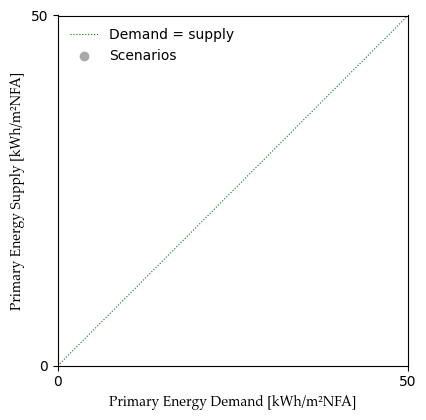

In [36]:
df = project.view.select(
    pexl.glossary.PEI_virtual_demand,
    pexl.glossary.PEI_virtual_supply,
).to_frame()

x = pd.to_numeric(df["PEI_virtual_demand"], errors="coerce")
y = pd.to_numeric(df["PEI_virtual_supply"], errors="coerce")

limit = np.nanmax([x.max(), y.max()])
limit = max(50, np.ceil(limit / 50) * 50)

fig, ax = plt.subplots(1, 1, figsize=(7, 4.3))

ax.plot(
    [0, limit],
    [0, limit],
    color="green",
    linestyle="dotted",
    linewidth=0.8,
    label="Demand = supply",
)

ax.scatter(
    x,
    y,
    color="darkgrey",
    label="Scenarios",
)

ax.set_aspect("equal", adjustable="box")
ax.set_xlim(0, limit)
ax.set_ylim(0, limit)

ticks = np.arange(0, limit + 1, 50)
ax.set_xticks(ticks)
ax.set_yticks(ticks)

ax.set_xlabel(
    "Primary Energy Demand [kWh/m²NFA]",
    fontname="Palatino Linotype",
)
ax.set_ylabel(
    "Primary Energy Supply [kWh/m²NFA]",
    fontname="Palatino Linotype",
)

ax.legend(frameon=False)

plt.tight_layout()
plt.show()

Because `df` is an ordinary DataFrame, scenario families, parameter sweeps or other analysis-specific groupings can be added as columns and passed directly to matplotlib, seaborn or Plotly.

# One-scenario workflows

## 16. Select results from one scenario

In [37]:
scenario = project[1]

heat = scenario.out.select(
    domain="heat_balance"
)

heat

var_name,label,unit,value
QT,Transmissionswärmeverl.,kWh/m²NGFa,35.777835
QV,Lüftungswärmeverluste,kWh/m²NGFa,62.127548
QVn,Nachtlüftung,kWh/m²NGFa,0.000000
QS,Solare Gewinne,kWh/m²NGFa,23.241977
QI,Innere Wärmen,kWh/m²NGFa,42.839142
QH,Heizwärmebedarf,kWh/m²NGFa,31.824264
QC,Kühlbedarf (KB),kWh/m²NGFa,0.000000
QV_heatrecovery,ML Wärmerückgewinnung,kWh/m²NGFa,0.000000
QT_winter,Transmissionswärmeverl.,kWh/m²NGFa,21.060507
QV_winter,Lüftungswärmeverluste,kWh/m²NGFa,36.571181


In [38]:
heat.to_var_dict()

{'QT': 35.777835008487926,
 'QV': 62.12754776490126,
 'QVn': 0,
 'QS': 23.24197733889779,
 'QI': 42.839141611383184,
 'QH': 31.824263823108204,
 'QC': 0,
 'QV_heatrecovery': 0,
 'QT_winter': 21.060507293332606,
 'QV_winter': 36.57118080255989,
 'QVn_winter': 0,
 'QS_winter': 8.837699689694388,
 'QI_winter': 16.695869627970044,
 'QH_winter': 31.824263823108208,
 'QC_winter': 0,
 'test_heat_balance_winter': 0.2738549551198517,
 'QT_wall_winter': 7.157538530805357,
 'QT_roof_winter': 2.2206472073832924,
 'QT_ground_winter': 2.5712757138122324,
 'QT_window_winter': 7.1964542692105775,
 'QT_psi_winter': 1.9145915721211464,
 'QV_inf_winter': 9.973958400697043,
 'QV_window_winter': 0,
 'QV_mechvent_winter': 26.597222401862844,
 'QV_heatrecovery_winter': 0,
 'QH_min_winter': 31.824263823108208,
 'QH_flex_winter': 0,
 'QC_min_winter': 0,
 'QC_flex_winter': 0,
 'QH_flexshare_winter': 0,
 'QC_flexshare_winter': 0,
 'QT_summer': 10.325989325426605,
 'QV_summer': 17.930889191118037,
 'QVn_summer': 

In [39]:
print("QH:", heat.QH)

QH: 31.824263823108204


## 17. Select related inputs

Example: residential-use inputs:

In [40]:
residential_inputs = scenario.inn.select(
    entity_group="usage",
    entity_key="residential",
)

residential_inputs.to_var_dict()

{'GFA_residential': 6887.56,
 'NFA_to_GFA_ratio_residential': 0.8,
 'NFA_residential': 5510.048000000001,
 'renovation_ratio_residential': 0,
 'rh_residential': 2.89,
 'fc_residential': 1,
 'illuminance_min_residential': 300,
 'vent_share_mechanical_residential': 1,
 'vent_night_residential': 'Querlüftung 32% (10cm Spalt)',
 'vent_ach_max_residential': 0.40000000000005964,
 'vent_scale_residential': 1.000000000000149,
 'Ev_scale_residential': 0.5,
 'vent_heat_recovery_winter_residential': 0,
 'vent_heat_recovery_summer_residential': 0,
 'usage_concurrency_winter_residential': 1,
 'usage_concurrency_summer_residential': 1,
 'DHW_demand_residential_kWhm2': 12.780000000000001,
 'aux_el_demand_residential_kWhm2': 1.7520000000002613,
 'Plugloads_scale_residential': 1,
 'density_NFApPers_residential': 41.7,
 'cool_share_residential': 0,
 'DHW_1_share_residential': 1,
 'DHW_occupancy_residential': 41.7,
 'DHW_concurrency_residential': 0.1,
 'StatPAX_residential': 132.13544364508394,
 'plugloa

Example: heating-system inputs:

In [41]:
heating_inputs = scenario.inn.select(
    entity_group="heating"
)

heating_inputs

var_name,label,unit,value
QHmax_1el_m2,Thermische Leistung HZEL1,W/m²,0
QHmax_2th_m2,Thermische Leistung HZTH2,W/m²,150
QHmax_3el_m2,Thermische Leistung HZEL3,W/m²,0
QHmax_4th_m2,Thermische Leistung HZTH4,W/m²,0
QH_distr_loss_1el,Verteilverluste HZEL1,ratio,0.05
QH_distr_loss_2th,Verteilverluste HZTH2,ratio,0.05
QH_distr_loss_3el,Verteilverluste HZEL3,ratio,0.05
QH_distr_loss_4th,Verteilverluste HZTH4,ratio,0
heat_cop_1el,Wirkungsgrad Erzeugung HZEL1,ratio,4.6
heat_cop_2th,Wirkungsgrad Erzeugung HZTH2,ratio,0.95


## 18. Change input values

Scenario values are changed through `scenario.v`.

The actual assignment is commented out so running the notebook does not modify the project accidentally.

In [42]:
scenario_edit = project[1]

print("Before:", scenario_edit.v.GFA_office)

# scenario_edit.v.GFA_office = 250.0

print("After:", scenario_edit.v.GFA_office)

Before: 0
After: 0


PEExcel formulas are not recalculated by Python automatically unless the workflow explicitly runs Excel or another calculation step.

# Creating and exporting projects

## 19. Create a project or scenario

In [43]:
from pexl.model.scenario import Scenario

new_project = Project()

new_scenario = Scenario(
    "Example Project | Variant A"
)

new_scenario.v.project_name = "Example Project"
new_scenario.v.project_scenario_name = "Variant A"
new_scenario.v.GFA_office = 250.0

new_project.add_scenario(new_scenario)

new_project

<Project scenarios=1 warnings=0>

When creating a new scenario, use a unique `column_name`. The conventional form is:

```text
project_name | project_scenario_name
```

## 20. Export a project

In [44]:
OUTPUT_PATH = Path("../data/exports/new_project.xlsx")

# Uncomment to write the file:
# new_project.to_excel(OUTPUT_PATH)

# Quick reference

| Task | Example |
|---|---|
| Open project | `project = Project.from_excel(path)` |
| First scenario | `project[0]` |
| Scenario by exact column | `project["Project | Variant"]` |
| Read one value | `scenario.v.GFA_total` |
| Discover metadata | `pexl.glossary.GFA_total` |
| List variables | `project.variables.var_names` |
| Select explicit variables | `project.view.select("A", "B")` |
| Select glossary variables | `project.view.select(pexl.glossary.A, pexl.glossary.B)` |
| Select inputs | `project.inn.select(...)` |
| Select outputs | `project.out.select(...)` |
| Select by domain | `project.out.select(domain="...")` |
| Filter scenarios | `project.where(project_name="...")` |
| List domains | `project.out.domains()` |
| List measures | `project.out.measures()` |
| Unique scenario values | `project.view.scenarios.unique("project_name")` |
| DataFrame | `view.to_frame()` |
| Available standard charts | `reporting.chart_names()` |
| Standard Plotly chart | `plotly.render(reporting.materialize(project.view, "heat_balance"))` |
| Modify value | `scenario.v.GFA_office = 250.0` |
| Export | `project.to_excel(path)` |